# Ejercicio de penetracion indoor en edificio real

## Objetivo
Adaptar un caso de cobertura indoor a un edificio docente real para decidir si la cobertura macro exterior es suficiente o si hace falta refuerzo indoor para voz, mensajeria y acceso a plataformas digitales.

## Escenario
- Edificio de varias plantas con fachada, tabiqueria interior y un semisotano tecnico.
- Estacion base exterior en entorno campus.
- Altura de antena exterior: 22 m.
- Portadora principal: LTE 1800 MHz.
- Portadora de respaldo: UMTS 2100 MHz.
- Extension opcional: comparar con 800 MHz y 2600 MHz.

## Tareas
1. Definir tres puntos de usuario: entrada, aula de segunda planta y semisotano.
2. Calcular la perdida total: propagacion exterior + penetracion interior.
3. Comprobar si el nivel recibido supera los umbrales de servicio.
4. Recomendar macro suficiente o refuerzo indoor.

## Hipotesis de calculo

Se usa un modelo simplificado de enlace descendente con una perdida exterior tipo 3GPP UMa NLOS conservadora y un margen de sombra adicional.

- EIRP sector macro: 58 dBm
- Margen exterior adicional: 8 dB
- Umbral de voz y mensajeria: -100 dBm
- Umbral de datos basicos y acceso a plataformas: -95 dBm

Perdidas interiores de referencia:
- Fachada: 12 a 18 dB
- Pared interior: 3 a 5 dB
- Forjado: 12 a 18 dB
- Puerta tecnica corta-fuegos: 6 dB

Puntos de usuario seleccionados:
- Entrada principal
- Aula de segunda planta
- Archivo en semisotano

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 1)

In [2]:
EIRP_DBM = 58
SHADOW_MARGIN_DB = 8
VOICE_THRESHOLD_DBM = -100
DATA_THRESHOLD_DBM = -95
BS_HEIGHT_M = 22

points = [
    {
        'punto': 'Entrada principal',
        'planta': 'Baja',
        'altura_usuario_m': 1.5,
        'distancia_horizontal_m': 180,
        'fachada_db': 14,
        'paredes_db': 0,
        'forjados_db': 0,
        'extra_db': 0,
    },
    {
        'punto': 'Aula 2a planta',
        'planta': 'Segunda',
        'altura_usuario_m': 8.5,
        'distancia_horizontal_m': 170,
        'fachada_db': 16,
        'paredes_db': 4,
        'forjados_db': 15,
        'extra_db': 0,
    },
    {
        'punto': 'Archivo semisotano',
        'planta': 'Semisotano',
        'altura_usuario_m': -2.5,
        'distancia_horizontal_m': 185,
        'fachada_db': 18,
        'paredes_db': 8,
        'forjados_db': 18,
        'extra_db': 6,
    },
]

bands_mhz = {
    'LTE 1800': 1800,
    'UMTS 2100': 2100,
    'LTE 800': 800,
    'LTE 2600': 2600,
}

In [3]:
def outdoor_path_loss_db(distance_horizontal_m, user_height_m, frequency_mhz, shadow_margin_db=SHADOW_MARGIN_DB):
    """Modelo conservador tipo UMa NLOS con termino de frecuencia en GHz."""
    distance_3d_m = math.sqrt(distance_horizontal_m ** 2 + (BS_HEIGHT_M - user_height_m) ** 2)
    frequency_ghz = frequency_mhz / 1000
    return (
        13.54
        + 39.08 * math.log10(distance_3d_m)
        + 20 * math.log10(frequency_ghz)
        - 0.6 * (user_height_m - 1.5)
        + shadow_margin_db
    )


def classify_service(received_power_dbm):
    if received_power_dbm >= DATA_THRESHOLD_DBM:
        return 'Cumple voz y datos basicos'
    if received_power_dbm >= VOICE_THRESHOLD_DBM:
        return 'Cumple voz, datos justos'
    return 'No cumple objetivo'


def recommendation(received_power_dbm, point_name):
    if received_power_dbm >= DATA_THRESHOLD_DBM:
        if 'Entrada' in point_name:
            return 'Macro suficiente'
        return 'Macro suficiente para el objetivo base'
    if received_power_dbm >= VOICE_THRESHOLD_DBM:
        return 'Revisar refuerzo ligero: repetidor o small cell segun capacidad'
    return 'Refuerzo indoor necesario: small cell o DAS; repetidor solo si la senal donante es estable'

In [4]:
rows = []
for band_name, frequency_mhz in bands_mhz.items():
    for point in points:
        outdoor_loss = outdoor_path_loss_db(
            point['distancia_horizontal_m'],
            point['altura_usuario_m'],
            frequency_mhz,
        )
        indoor_loss = point['fachada_db'] + point['paredes_db'] + point['forjados_db'] + point['extra_db']
        total_loss = outdoor_loss + indoor_loss
        received_power = EIRP_DBM - total_loss
        rows.append({
            'banda': band_name,
            'punto': point['punto'],
            'planta': point['planta'],
            'dist_h_m': point['distancia_horizontal_m'],
            'L_ext_db': round(outdoor_loss, 1),
            'L_fachada_db': point['fachada_db'],
            'L_paredes_db': point['paredes_db'],
            'L_forjados_db': point['forjados_db'],
            'L_extra_db': point['extra_db'],
            'L_total_db': round(total_loss, 1),
            'P_rx_dbm': round(received_power, 1),
            'estado': classify_service(received_power),
            'recomendacion': recommendation(received_power, point['punto']),
        })

results = pd.DataFrame(rows)
main_results = results[results['banda'].isin(['LTE 1800', 'UMTS 2100'])].copy()
main_results

,banda,punto,planta,dist_h_m,L_ext_db,L_fachada_db,L_paredes_db,L_forjados_db,L_extra_db,L_total_db,P_rx_dbm,estado,recomendacion
0,LTE 1800,Entrada principal,Baja,180,114.9,14,0,0,0,128.9,-70.9,Cumple voz y datos basicos,Macro suficiente
1,LTE 1800,Aula 2a planta,Segunda,170,109.7,16,4,15,0,144.7,-86.7,Cumple voz y datos basicos,Macro suficiente para el objetivo base
2,LTE 1800,Archivo semisotano,Semisotano,185,117.8,18,8,18,6,167.8,-109.8,No cumple objetivo,Refuerzo indoor necesario: small cell o DAS; r...
3,UMTS 2100,Entrada principal,Baja,180,116.2,14,0,0,0,130.2,-72.2,Cumple voz y datos basicos,Macro suficiente
4,UMTS 2100,Aula 2a planta,Segunda,170,111.0,16,4,15,0,146.0,-88.0,Cumple voz y datos basicos,Macro suficiente para el objetivo base
5,UMTS 2100,Archivo semisotano,Semisotano,185,119.1,18,8,18,6,169.1,-111.1,No cumple objetivo,Refuerzo indoor necesario: small cell o DAS; r...


## Tabla de perdidas por tramo

La tabla siguiente resume el caso principal con LTE 1800. Es el entregable minimo para el alumno.

In [5]:
lte_1800 = results[results['banda'] == 'LTE 1800'][[
    'punto',
    'L_ext_db',
    'L_fachada_db',
    'L_paredes_db',
    'L_forjados_db',
    'L_extra_db',
    'L_total_db',
    'P_rx_dbm',
    'estado',
    'recomendacion',
]]
lte_1800

,punto,L_ext_db,L_fachada_db,L_paredes_db,L_forjados_db,L_extra_db,L_total_db,P_rx_dbm,estado,recomendacion
0,Entrada principal,114.9,14,0,0,0,128.9,-70.9,Cumple voz y datos basicos,Macro suficiente
1,Aula 2a planta,109.7,16,4,15,0,144.7,-86.7,Cumple voz y datos basicos,Macro suficiente para el objetivo base
2,Archivo semisotano,117.8,18,8,18,6,167.8,-109.8,No cumple objetivo,Refuerzo indoor necesario: small cell o DAS; r...


In [6]:
summary = lte_1800[['punto', 'P_rx_dbm', 'estado', 'recomendacion']].copy()
summary

,punto,P_rx_dbm,estado,recomendacion
0,Entrada principal,-70.9,Cumple voz y datos basicos,Macro suficiente
1,Aula 2a planta,-86.7,Cumple voz y datos basicos,Macro suficiente para el objetivo base
2,Archivo semisotano,-109.8,No cumple objetivo,Refuerzo indoor necesario: small cell o DAS; r...


## Plantilla formal de croquis para entrega docente

La figura siguiente sustituye al croquis esquematico inicial por una plantilla mas formal de entrega. Mantiene el caracter docente, pero introduce elementos utiles para memoria o practicas evaluables:

- Titulo tecnico del plano.
- Identificacion codificada de puntos de medida: P1, P2 y P3.
- Leyenda de elementos constructivos y de radio.
- Cuadro lateral con parametros base del caso.
- Espacio para anotar observaciones de campo.

En un trabajo con plano real, esta misma estructura debe colocarse sobre la planta del edificio en QGIS o en el plano CAD exportado a imagen o PDF.

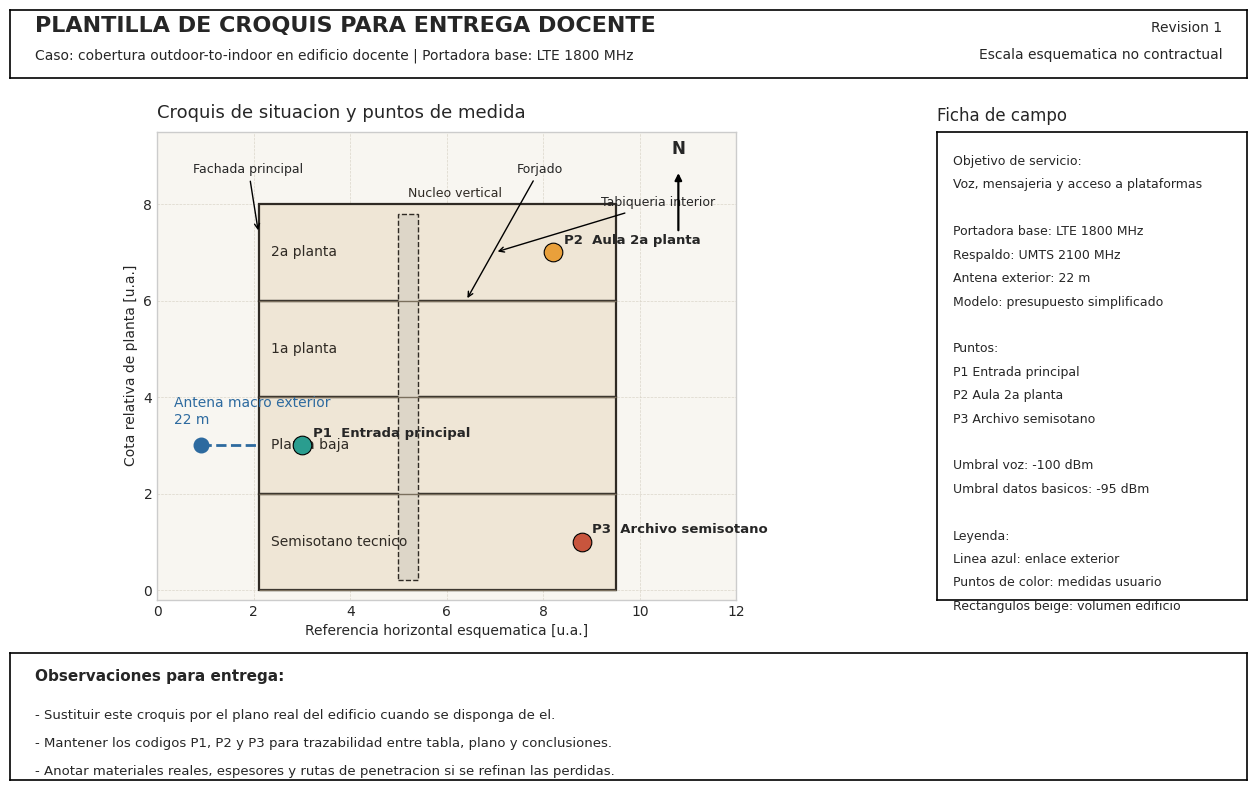

In [7]:
fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(3, 4, width_ratios=[3.6, 3.6, 0.2, 2.6], height_ratios=[0.7, 4.8, 1.3])

ax_title = fig.add_subplot(gs[0, :])
ax_plan = fig.add_subplot(gs[1, 0:2])
ax_side = fig.add_subplot(gs[1, 3])
ax_notes = fig.add_subplot(gs[2, :])

for axis in [ax_title, ax_side, ax_notes]:
    axis.set_xticks([])
    axis.set_yticks([])
    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color('black')

ax_title.set_xlim(0, 1)
ax_title.set_ylim(0, 1)
ax_title.text(0.02, 0.68, 'PLANTILLA DE CROQUIS PARA ENTREGA DOCENTE', fontsize=16, fontweight='bold')
ax_title.text(0.02, 0.28, 'Caso: cobertura outdoor-to-indoor en edificio docente | Portadora base: LTE 1800 MHz', fontsize=10)
ax_title.text(0.98, 0.68, 'Revision 1', ha='right', fontsize=10)
ax_title.text(0.98, 0.28, 'Escala esquematica no contractual', ha='right', fontsize=10)

ax_plan.set_xlim(0, 12)
ax_plan.set_ylim(-0.2, 9.5)
ax_plan.set_aspect('equal')
ax_plan.set_title('Croquis de situacion y puntos de medida', loc='left', fontsize=13, pad=10)
ax_plan.set_facecolor('#f8f6f1')
ax_plan.grid(True, linestyle='--', linewidth=0.5, color='#d8d2c6', alpha=0.9)

building_fill = '#efe6d6'
floor_line = '#7a6f5d'
wall_line = '#2f2a24'

floors = [
    ('2a planta', 6.0, 8.0),
    ('1a planta', 4.0, 6.0),
    ('Planta baja', 2.0, 4.0),
    ('Semisotano tecnico', 0.0, 2.0),
]

for label, y0, y1 in floors:
    ax_plan.add_patch(plt.Rectangle((2.1, y0), 7.4, y1 - y0, facecolor=building_fill, edgecolor=wall_line, linewidth=1.6))
    ax_plan.hlines(y0, 2.1, 9.5, colors=floor_line, linewidth=1.0)
    ax_plan.text(2.35, (y0 + y1) / 2, label, va='center', fontsize=10, color=wall_line)

ax_plan.add_patch(plt.Rectangle((5.0, 0.2), 0.4, 7.6, facecolor='#ddd6c8', edgecolor=wall_line, linewidth=1.0, linestyle='--'))
ax_plan.text(5.2, 8.15, 'Nucleo vertical', fontsize=9, color=wall_line)

ax_plan.plot([0.9, 2.1], [3.0, 3.0], linestyle='--', color='#2d6a9f', linewidth=2.0)
ax_plan.scatter([0.9], [3.0], color='#2d6a9f', s=110, zorder=5)
ax_plan.text(0.35, 3.45, 'Antena macro exterior\n22 m', color='#2d6a9f', fontsize=10)

points_plot = {
    'P1': {'name': 'Entrada principal', 'xy': (3.0, 3.0), 'color': '#2a9d8f'},
    'P2': {'name': 'Aula 2a planta', 'xy': (8.2, 7.0), 'color': '#e9a03b'},
    'P3': {'name': 'Archivo semisotano', 'xy': (8.8, 1.0), 'color': '#c8553d'},
}

for code, info in points_plot.items():
    x_pos, y_pos = info['xy']
    ax_plan.scatter([x_pos], [y_pos], color=info['color'], s=180, edgecolor='black', linewidth=0.8, zorder=6)
    ax_plan.text(x_pos + 0.22, y_pos + 0.18, f'{code}  {info["name"]}', fontsize=9.5, weight='bold')

ax_plan.annotate('Fachada principal', xy=(2.1, 7.4), xytext=(0.75, 8.65), arrowprops={'arrowstyle': '->', 'linewidth': 1.0}, fontsize=9)
ax_plan.annotate('Forjado', xy=(6.4, 6.0), xytext=(7.45, 8.65), arrowprops={'arrowstyle': '->', 'linewidth': 1.0}, fontsize=9)
ax_plan.annotate('Tabiqueria interior', xy=(7.0, 7.0), xytext=(9.2, 7.95), arrowprops={'arrowstyle': '->', 'linewidth': 1.0}, fontsize=9)

ax_plan.annotate('', xy=(10.8, 8.7), xytext=(10.8, 7.4), arrowprops={'arrowstyle': '-|>', 'linewidth': 1.6, 'color': 'black'})
ax_plan.text(10.8, 8.95, 'N', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax_plan.set_xlabel('Referencia horizontal esquematica [u.a.]')
ax_plan.set_ylabel('Cota relativa de planta [u.a.]')

ax_side.set_xlim(0, 1)
ax_side.set_ylim(0, 1)
ax_side.set_title('Ficha de campo', loc='left', fontsize=12, pad=8)
side_lines = [
    'Objetivo de servicio:',
    'Voz, mensajeria y acceso a plataformas',
    '',
    'Portadora base: LTE 1800 MHz',
    'Respaldo: UMTS 2100 MHz',
    'Antena exterior: 22 m',
    'Modelo: presupuesto simplificado',
    '',
    'Puntos:',
    'P1 Entrada principal',
    'P2 Aula 2a planta',
    'P3 Archivo semisotano',
    '',
    'Umbral voz: -100 dBm',
    'Umbral datos basicos: -95 dBm',
    '',
    'Leyenda:',
    'Linea azul: enlace exterior',
    'Puntos de color: medidas usuario',
    'Rectangulos beige: volumen edificio',
]
for idx, line in enumerate(side_lines):
    ax_side.text(0.05, 0.95 - idx * 0.05, line, fontsize=9, va='top')

ax_notes.set_xlim(0, 1)
ax_notes.set_ylim(0, 1)
ax_notes.text(0.02, 0.78, 'Observaciones para entrega:', fontsize=11, fontweight='bold')
ax_notes.text(0.02, 0.48, '- Sustituir este croquis por el plano real del edificio cuando se disponga de el.', fontsize=9.5)
ax_notes.text(0.02, 0.26, '- Mantener los codigos P1, P2 y P3 para trazabilidad entre tabla, plano y conclusiones.', fontsize=9.5)
ax_notes.text(0.02, 0.04, '- Anotar materiales reales, espesores y rutas de penetracion si se refinan las perdidas.', fontsize=9.5)

plt.tight_layout()
plt.show()

## Traslado del caso a QGIS con plano real



Para pasar de la plantilla esquematica a un caso mas realista, el repositorio incorpora una guia y una plantilla de capa en formato CSV:



- `qgis/guia_qgis_plano_real.md`

- `qgis/puntos_medida_template.csv`



Uso recomendado:



1. Cargar el plano real del edificio en QGIS.

2. Georreferenciarlo si procede.

3. Importar la plantilla CSV como capa de puntos.

4. Ajustar las coordenadas y atributos a la realidad del edificio.

5. Conservar los codigos P1, P2 y P3 para enlazar plano, tabla y conclusion.

## Extension opcional por banda

La comparativa ayuda a reforzar la idea de que frecuencias mas bajas penetran mejor y frecuencias mas altas penalizan la cobertura indoor.

In [8]:
comparison = results.pivot(index='punto', columns='banda', values='P_rx_dbm').round(1)
comparison

banda,LTE 1800,LTE 2600,LTE 800,UMTS 2100
punto,,,,
Archivo semisotano,-109.8,-113.0,-102.8,-111.1
Aula 2a planta,-86.7,-89.9,-79.6,-88.0
Entrada principal,-70.9,-74.1,-63.8,-72.2


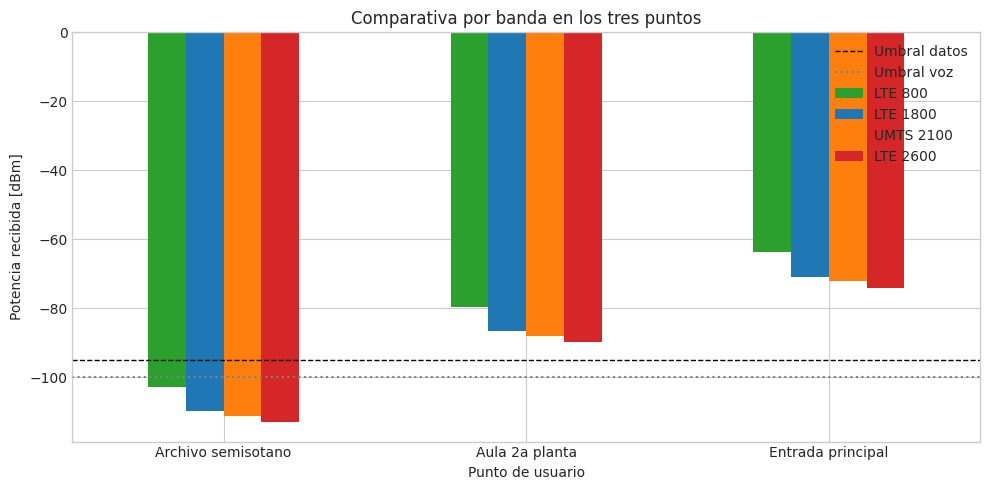

In [9]:
ax = comparison[['LTE 800', 'LTE 1800', 'UMTS 2100', 'LTE 2600']].plot(
    kind='bar',
    figsize=(10, 5),
    color=['tab:green', 'tab:blue', 'tab:orange', 'tab:red']
)
ax.axhline(DATA_THRESHOLD_DBM, color='black', linestyle='--', linewidth=1, label='Umbral datos')
ax.axhline(VOICE_THRESHOLD_DBM, color='gray', linestyle=':', linewidth=1.5, label='Umbral voz')
ax.set_ylabel('Potencia recibida [dBm]')
ax.set_xlabel('Punto de usuario')
ax.set_title('Comparativa por banda en los tres puntos')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
output_dir = Path('salidas')
output_dir.mkdir(exist_ok=True)
lte_1800.to_csv(output_dir / 'tabla_perdidas_lte1800.csv', index=False)
comparison.to_csv(output_dir / 'comparativa_bandas.csv')
summary.to_csv(output_dir / 'resumen_recomendaciones.csv', index=False)
print('Archivos exportados en', output_dir.resolve())

Archivos exportados en /workspaces/Cobertura-indoor-de-campus/salidas


## Conclusion esperada

Con los parametros elegidos, el ejercicio conduce a una conclusion razonable y facil de defender:

- La entrada principal queda cubierta por macro exterior.
- El aula de segunda planta cumple el objetivo base, pero con menos margen que la entrada.
- El semisotano no alcanza el objetivo y requiere refuerzo indoor.

Criterio de solucion de mejora:
- Small cell: preferible si se quiere servicio dedicado y buena capacidad para plataformas digitales.
- DAS: preferible si hay que repartir cobertura en varias plantas o dar servicio multioperador.
- Repetidor: solo cuando la senal donante exterior sea estable y la normativa lo permita.